# Detecção de Careless/Insufficient Effort Responding (C/IER)

Pablo Rogers [](https://orcid.org/0000-0002-0093-3834) (Universidade Federal de Uberlândia)  
April 3, 2026

This… (abstract text here)

In [ ]:
# Pacotes necessários
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## Leitura e preparação dos dados

O arquivo `data.csv` contém as respostas brutas do questionário (separador `;`). Nesta etapa, removem-se registros de abandono, selecionam-se as variáveis do fluxo analítico e deriva-se o tempo total de resposta (`TIME`).

In [ ]:
# Leitura do arquivo com separador ";"
dados_brutos <- read_csv2("Data/InputData/data.csv", show_col_types = FALSE)

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

Rows: 1,326
Columns: 33
$ ID       <dbl> 10441016017, 10440981694, 10440601239, 10440562981, 104403585…
$ CREATED  <chr> "28/12/2018 12:00", "28/12/2018 11:25", "28/12/2018 03:23", "…
$ MODIFIED <chr> "28/12/2018 12:20", "28/12/2018 11:47", "28/12/2018 03:39", "…
$ CQ1      <dbl> 1, 1, 1, 1, 1, 1, 1, 1, NA, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ CQ2      <dbl> 1, 1, 1, 1, 1, 1, 1, 1, NA, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ CQ3      <dbl> 1, 1, 1, 1, 1, 1, 1, 1, NA, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ Q1       <dbl> 5, 3, 1, 4, 3, 4, 3, 4, 2, 5, 4, 3, 4, 2, 4, 5, 4, 5, 4, 4, 4…
$ Q2       <dbl> 5, 4, 1, 4, 4, 4, 4, 4, 2, 5, 4, NA, 4, 1, 4, 5, 4, 4, 4, 4, …
$ Q3       <dbl> 1, 2, 3, 2, 1, 1, 1, 1, 4, 2, 3, 2, 2, 3, 3, 1, 2, 2, 2, 3, 1…
$ Q4       <dbl> 1, 2, 2, 1, 1, 1, 2, 1, 4, 1, 3, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1…
$ Q5       <dbl> 3, 3, 1, 3, 3, 3, 3, 3, 1, 4, 3, 4, 4, 1, 3, 4, 3, 5, 3, 4, 3…
$ Q6       <dbl> 4, 4, 1, 3, 5, 4, 3, 4, 4, 4, 5, 3, 3, 4, 4, 5, 3, 5, 4, 4, 3…
$ Q7       <dbl>

## Exclusões procedimentais (Nível 1)

O Nível 1 aplica três procedimentos prévios ao cálculo dos indicadores post hoc: remoção de abandono, exclusão por tempo de resposta inferior a 208 segundos e exclusão por duas ou mais falhas nos itens de controle de qualidade (`CQ1-CQ3`).

In [ ]:
# Regras procedimentais do Nível 1
dados_nivel1 <- dados_importados |>
  mutate(
    cq_falhas = rowSums(across(CQ1:CQ3, \(x) x != 1), na.rm = TRUE),
    excl_time = TIME < 208,
    excl_cq = cq_falhas >= 2,
    nivel1_excluido = excl_time | excl_cq
  )

# Log de exclusões
exclusion_log <- bind_rows(
  dados_preparados |>
    filter(abandono) |>
    transmute(
      ID,
      criterio = "abandono",
      valor = NA_real_,
      detalhe = "Sem respostas válidas em Q1-Q26"
    ),
  dados_nivel1 |>
    filter(excl_time) |>
    transmute(
      ID,
      criterio = "time_rapido",
      valor = TIME,
      detalhe = paste0("TIME = ", TIME, " s")
    ),
  dados_nivel1 |>
    filter(excl_cq) |>
    transmute(
      ID,
      criterio = "cq_falhas",
      valor = cq_falhas,
      detalhe = paste0("Falhas CQ = ", cq_falhas)
    )
) |>
  distinct(ID, criterio, .keep_all = TRUE)

dir.create("Output/Results", recursive = TRUE, showWarnings = FALSE)
write_csv2(exclusion_log, "Output/Results/exclusion_log.csv")

# Dados elegíveis para os indicadores C/IER (Nível 2)
dados_analise <- dados_nivel1 |>
  filter(!nivel1_excluido)

id_col <- dados_analise$ID

itens <- dados_analise |>
  select(Q1:Q26) |>
  mutate(across(everything(), as.numeric))

tibble(
  etapa = c("Dados brutos", "Abandono removido", "Excluídos por tempo", "Excluídos por CQ", "Elegíveis para Nível 2"),
  n = c(
    nrow(dados_brutos),
    sum(dados_preparados$abandono, na.rm = TRUE),
    sum(dados_nivel1$excl_time, na.rm = TRUE),
    sum(dados_nivel1$excl_cq, na.rm = TRUE),
    nrow(dados_analise)
  )
)

# A tibble: 5 × 2
  etapa                      n
  <chr>                  <int>
1 Dados brutos            1546
2 Abandono removido        220
3 Excluídos por tempo        0
4 Excluídos por CQ          28
5 Elegíveis para Nível 2  1298

## Cálculo dos indicadores C/IER

### Definição das funções auxiliares

In [ ]:
# --- Laz.R index (Biemann et al., 2025) ---
# Calcula a previsibilidade da cadeia de Markov para cada respondente.
# Valores altos indicam padrões de resposta previsíveis (e.g., repetição).
calc_lazr <- function(x) {
  tr <- table(x[-length(x)], x[-1], useNA = "ifany")
  sum(tr^2 / rowSums(tr)) / (length(x) - 1)
}

# --- Algoritmo Kneedle (Satopaa et al., 2011) ---
# Encontra o "cotovelo" em uma curva ordenada de valores.
# Código adaptado de: https://rdrr.io/github/MollahLab/gen3DNet/man/kneedle.html
dist2d <- function(a, b, c) {
  v1 <- b - c
  v2 <- a - b
  m  <- cbind(v1, v2)
  det(m) / sqrt(sum(v1 * v1))
}

kneedle <- function(values, sign) {
  start <- c(1, values[1])
  end   <- c(length(values), values[length(values)])
  which.max(lapply(seq_along(values), function(idx) {
    sign * -1 * dist2d(c(idx, values[idx]), start, end)
  }))
}

### Cálculo dos quatro indicadores

In [ ]:
# Laz.R — aplicado linha a linha
lazr_vals <- apply(itens, 1, calc_lazr)

# Longstring — maior sequência de respostas consecutivas idênticas
longstr_vals <- longstring(itens)

# Mahalanobis Distance (MD) — distância multivariada do centroide
md_vals <- if (sum(is.na(itens)) == 0) {
  mahad(itens, plot = FALSE)
} else {
  rep(NA_real_, nrow(itens))
}

# IRV — Intra-individual Response Variability (desvio-padrão intra-indivíduo)
irv_vals <- irv(itens, split = FALSE)

## Variáveis individuais

Cada respondente recebe os valores dos quatro indicadores em um tibble consolidado.

In [ ]:
df_indicadores <- tibble(
  ID      = id_col,
  LazR    = round(lazr_vals, 3),
  Longstr = as.integer(longstr_vals),
  MD      = round(md_vals, 3),
  IRV     = round(irv_vals, 3)
)

df_indicadores

# A tibble: 1,546 × 5
            ID  LazR Longstr    MD   IRV
         <dbl> <dbl>   <int> <dbl> <dbl>
 1 10441016017 0.384       7    NA  5.85
 2 10440981694 0.559      11    NA  5.62
 3 10440601239 0.446      15    NA  3.65
 4 10440562981 0.539      17    NA  4.61
 5 10440358563 0.585      35    NA  4.54
 6 10440199369 0.618      38    NA  4.88
 7 10439125905 0.755      22    NA  4.58
 8 10439033965 0.794       8    NA 10.0 
 9 10438952564 0.363       8    NA  2.36
10 10438951127 0.384      14    NA  4.54
# ℹ 1,536 more rows

## Visualização univariada

### Laz.R

``` r
p_hist_lazr <- ggplot(df_indicadores, aes(x = LazR)) +
  geom_histogram(bins = 40, fill = "#3B7DD8", color = "white", alpha = 0.85) +
  labs(title = "Laz.R", x = "Laz.R", y = "Frequência") +
  theme_light()

p_box_lazr <- ggplot(df_indicadores, aes(y = LazR)) +
  geom_boxplot(fill = "#3B7DD8", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "Laz.R") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_lazr + p_box_lazr + plot_layout(widths = c(3, 1))
```

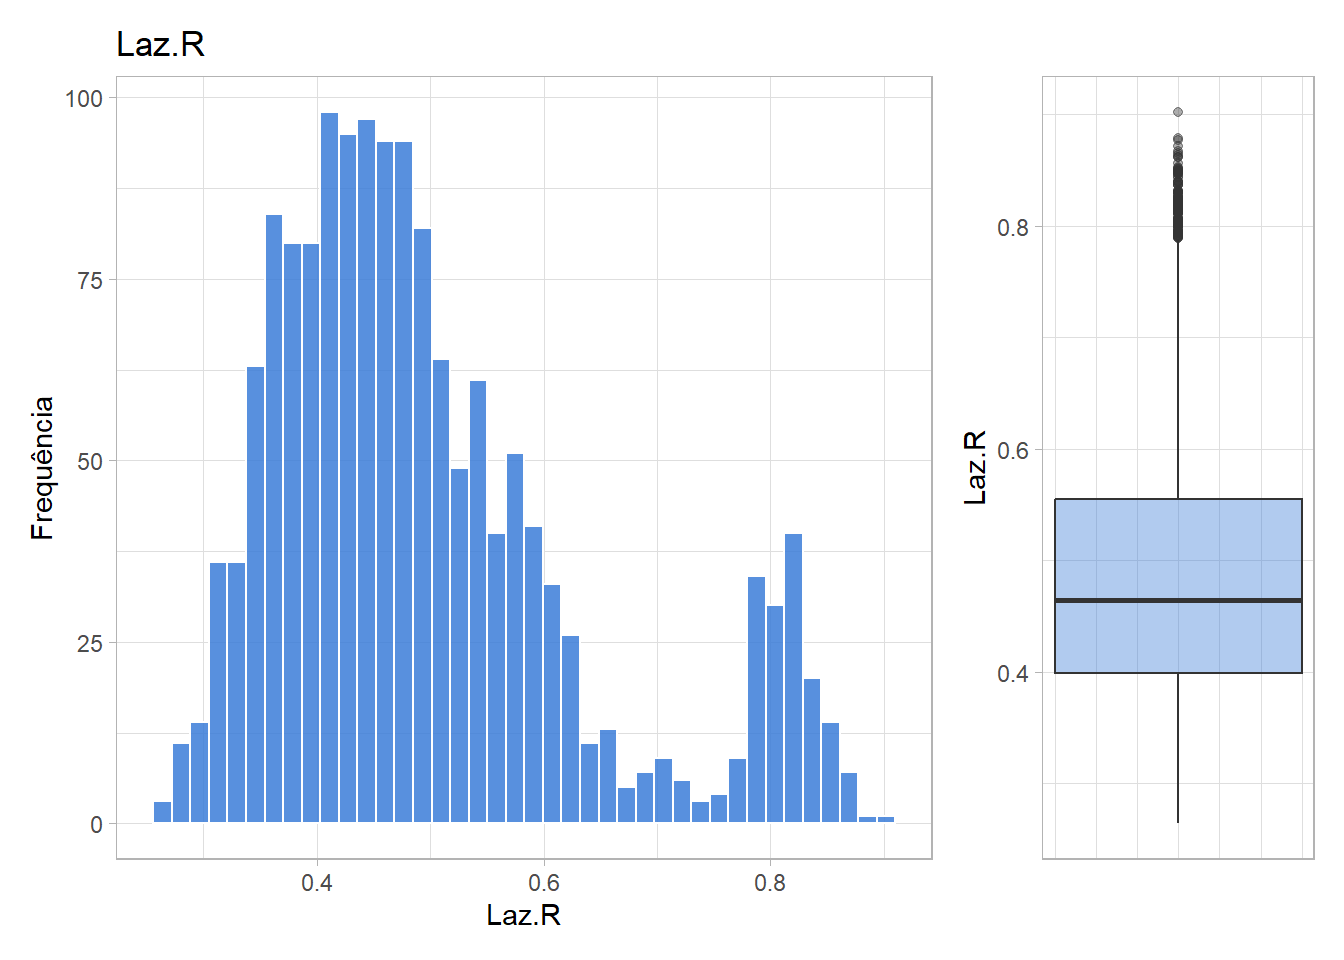

### Longstring

``` r
p_hist_ls <- ggplot(df_indicadores, aes(x = Longstr)) +
  geom_histogram(binwidth = 1, fill = "#E07B39", color = "white", alpha = 0.85) +
  labs(title = "Longstring", x = "Longstring", y = "Frequência") +
  theme_light()

p_box_ls <- ggplot(df_indicadores, aes(y = Longstr)) +
  geom_boxplot(fill = "#E07B39", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "Longstring") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_ls + p_box_ls + plot_layout(widths = c(3, 1))
```

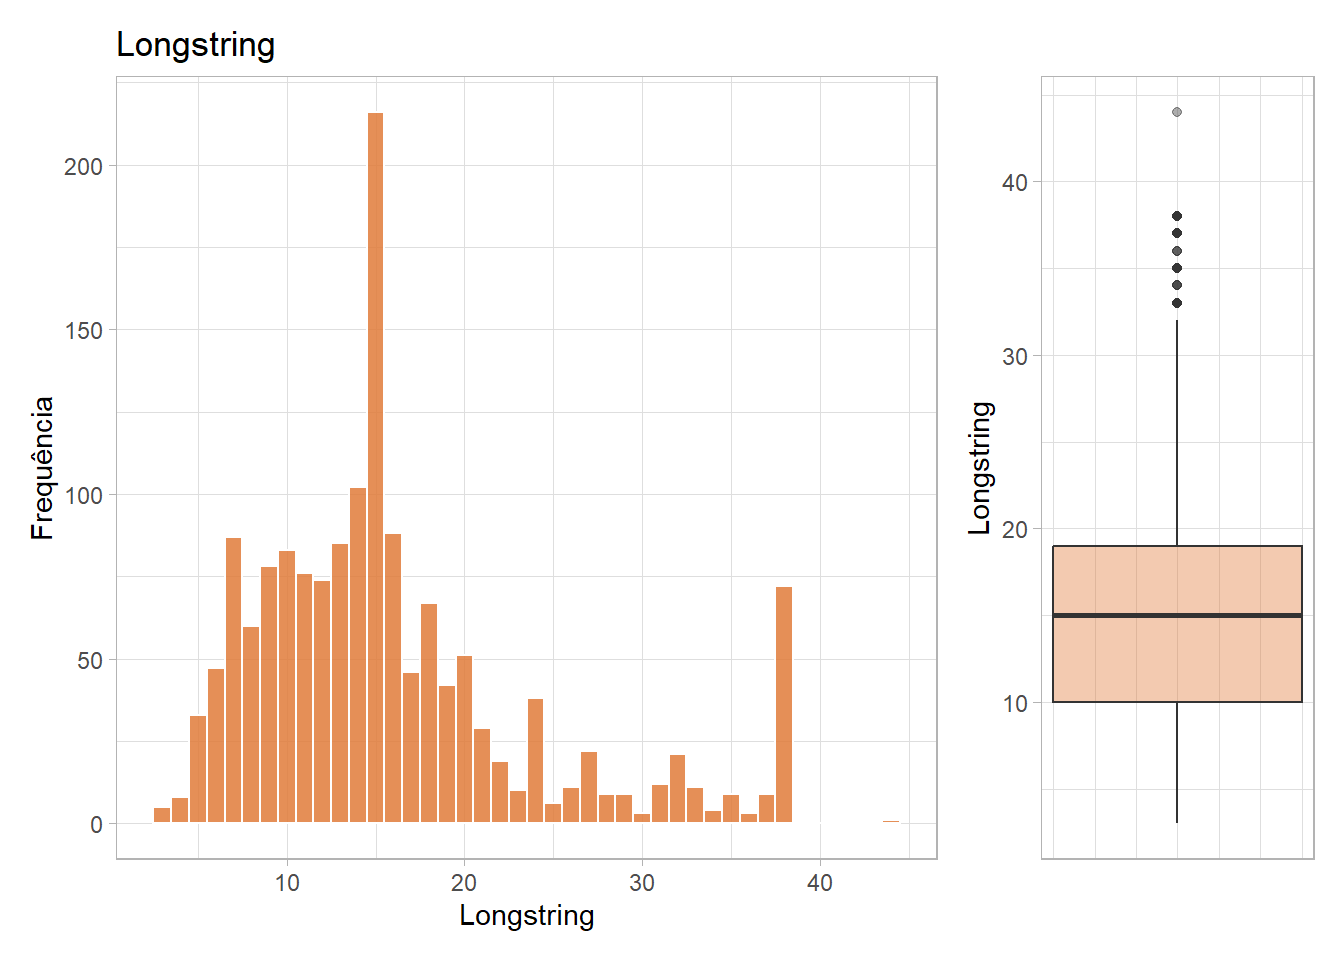

### Mahalanobis Distance

``` r
p_hist_md <- ggplot(df_indicadores, aes(x = MD)) +
  geom_histogram(bins = 40, fill = "#2CA02C", color = "white", alpha = 0.85) +
  labs(title = "Mahalanobis Distance", x = "MD", y = "Frequência") +
  theme_light()

p_box_md <- ggplot(df_indicadores, aes(y = MD)) +
  geom_boxplot(fill = "#2CA02C", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "MD") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_md + p_box_md + plot_layout(widths = c(3, 1))
```

    Warning: Removed 1546 rows containing non-finite outside the scale range
    (`stat_bin()`).

    Warning: Removed 1546 rows containing non-finite outside the scale range
    (`stat_boxplot()`).

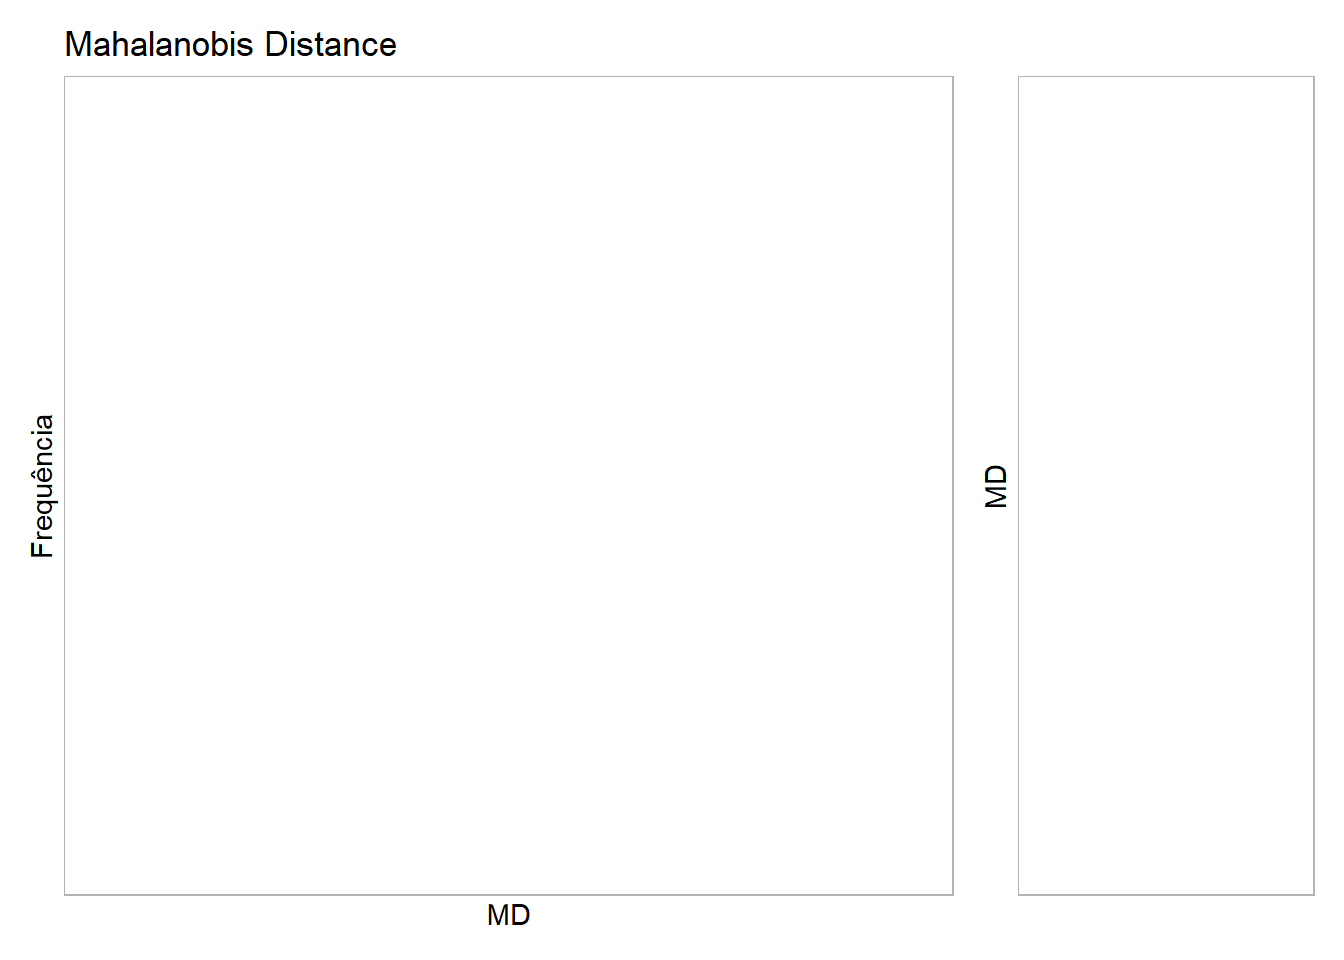

### IRV

``` r
p_hist_irv <- ggplot(df_indicadores, aes(x = IRV)) +
  geom_histogram(bins = 40, fill = "#9467BD", color = "white", alpha = 0.85) +
  labs(title = "IRV", x = "IRV", y = "Frequência") +
  theme_light()

p_box_irv <- ggplot(df_indicadores, aes(y = IRV)) +
  geom_boxplot(fill = "#9467BD", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "IRV") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_irv + p_box_irv + plot_layout(widths = c(3, 1))
```

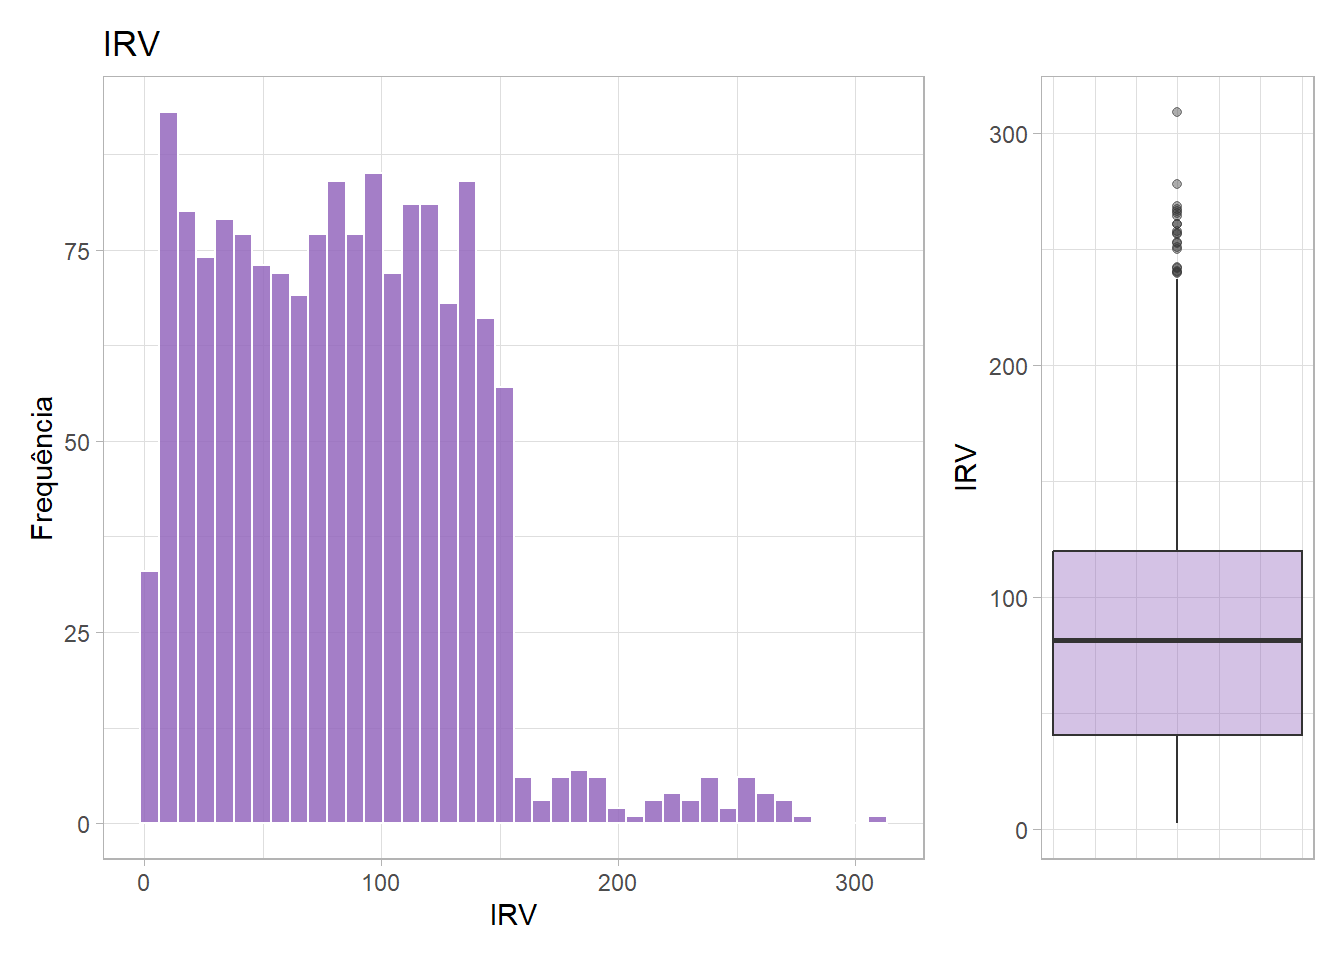

## Pontos de corte via algoritmo Kneedle

O kneedle é aplicado à curva ordenada (decrescente) de cada indicador.

-   Para **Laz.R**, **Longstring** e **MD**: o kneedle com `sign = -1` identifica onde os valores extremamente altos se separam da maioria (cauda direita).
-   Para **IRV**: usa-se `sign = -1` para detectar IRV alto demais (cauda direita) e `sign = +1` para IRV baixo demais (cauda esquerda), pois ambos extremos são suspeitos.

In [ ]:
# Função auxiliar: aplicar kneedle a um vetor e retornar percentil + valor crítico
calc_kneedle <- function(x, sign_val) {
  x_sorted <- sort(x, decreasing = TRUE, na.last = NA)
  n <- length(x_sorted)
  if (n == 0 || sum(x_sorted, na.rm = TRUE) == 0) {
    return(list(pct = NA_real_, crit = NA_real_, sorted = x_sorted))
  }
  pos <- kneedle(x_sorted, sign_val)
  pct <- pos / n
  crit <- quantile(x_sorted, probs = 1 - pct, na.rm = TRUE, names = FALSE)
  list(pct = pct, crit = crit, sorted = x_sorted)
}

# Laz.R — valores altos são suspeitos
kn_lazr <- calc_kneedle(df_indicadores$LazR, -1)

# Longstring — valores altos são suspeitos
kn_longstr <- calc_kneedle(df_indicadores$Longstr, -1)

# Mahalanobis Distance — valores altos são suspeitos
kn_md <- calc_kneedle(df_indicadores$MD, -1)

# IRV — ambas as caudas são suspeitas
kn_irv_high <- calc_kneedle(df_indicadores$IRV, -1)   # IRV alto demais
kn_irv_low  <- calc_kneedle(df_indicadores$IRV, +1)   # IRV baixo demais

# Tabela resumo dos pontos de corte
tab_cutoffs <- tibble(
  Indicador                   = c("Laz.R", "Longstring", "MD",
                                  "IRV (high end)", "IRV (low end)"),
  `Valor crítico`             = round(c(kn_lazr$crit, kn_longstr$crit, kn_md$crit,
                                        kn_irv_high$crit, kn_irv_low$crit), 2),
  `% suspeitos`               = round(c(
    kn_lazr$pct, kn_longstr$pct, kn_md$pct,
    kn_irv_high$pct, 1 - kn_irv_low$pct
  ) * 100, 1)
)

tab_cutoffs |>
  gt() |>
  tab_header(
    title    = "Pontos de corte — Algoritmo Kneedle",
    subtitle = "Satopaa et al. (2011); Biemann et al. (2025)"
  ) |>
  fmt_number(columns = `Valor crítico`, decimals = 2) |>
  fmt_number(columns = `% suspeitos`, decimals = 1)

## Flags de C/IER

Para cada indicador, cria-se uma variável `_FLAG` (`1` = suspeito, `0` = não suspeito) com base nos pontos de corte Kneedle:

-   **Laz.R** e **MD**: flag = 1 se valor ≥ valor crítico.
-   **Longstring**: flag = 1 se valor for estritamente maior que o valor crítico.
-   **IRV high**: flag = 1 se valor ≥ valor crítico (variação excessiva).
-   **IRV low**: flag = 1 se valor ≤ valor crítico (variação insuficiente).

In [ ]:
df_flags <- df_indicadores |>
  mutate(
    LazR_FLAG         = if_else(LazR    >= kn_lazr$crit,      1L, 0L),
    Longstr_FLAG      = if_else(Longstr >  kn_longstr$crit,   1L, 0L),
    MD_FLAG           = if_else(MD      >= kn_md$crit,        1L, 0L),
    IRV_high_FLAG     = if_else(IRV     >= kn_irv_high$crit,  1L, 0L),
    IRV_low_FLAG      = if_else(IRV     <= kn_irv_low$crit,   1L, 0L)
    )

df_flags

# A tibble: 1,546 × 10
            ID  LazR Longstr    MD   IRV LazR_FLAG Longstr_FLAG MD_FLAG
         <dbl> <dbl>   <int> <dbl> <dbl>     <int>        <int>   <int>
 1 10441016017 0.384       7    NA  5.85         0            0      NA
 2 10440981694 0.559      11    NA  5.62         0            0      NA
 3 10440601239 0.446      15    NA  3.65         0            0      NA
 4 10440562981 0.539      17    NA  4.61         0            0      NA
 5 10440358563 0.585      35    NA  4.54         0            1      NA
 6 10440199369 0.618      38    NA  4.88         1            1      NA
 7 10439125905 0.755      22    NA  4.58         1            1      NA
 8 10439033965 0.794       8    NA 10.0          1            0      NA
 9 10438952564 0.363       8    NA  2.36         0            0      NA
10 10438951127 0.384      14    NA  4.54         0            0      NA
# ℹ 1,536 more rows
# ℹ 2 more variables: IRV_high_FLAG <int>, IRV_low_FLAG <int>

### Resumo das flags

In [ ]:
df_flags |>
  summarise(
    across(ends_with("_FLAG"), list(
      n_suspeitos   = \(x) sum(x, na.rm = TRUE),
      pct_suspeitos = \(x) mean(x, na.rm = TRUE) * 100
    ))
  ) |>
  pivot_longer(everything(),
               names_to = c("Indicador", ".value"),
               names_pattern = "(.+)_(n_suspeitos|pct_suspeitos)") |>
  gt() |>
  tab_header(title = "Resumo de respondentes sinalizados como C/IER") |>
  fmt_number(columns = pct_suspeitos, decimals = 1) |>
  cols_label(
    Indicador     = "Indicador",
    n_suspeitos   = "N suspeitos",
    pct_suspeitos = "% suspeitos"
  )

## Exportação do arquivo com flags

O arquivo final `data_flag.csv` preserva as colunas originais de `data.csv`, adiciona as variáveis procedimentais do Nível 1 e as flags dos indicadores calculadas.

In [ ]:
data_flag <- dados_brutos |>
  left_join(
    dados_preparados |>
      transmute(ID, abandono = as.integer(abandono)),
    by = join_by(ID)
  ) |>
  left_join(
    dados_nivel1 |>
      transmute(
        ID,
        TIME,
        cq_falhas,
        excl_time = as.integer(excl_time),
        excl_cq = as.integer(excl_cq),
        nivel1_excluido = as.integer(nivel1_excluido)
      ),
    by = join_by(ID)
  ) |>
  left_join(
    df_flags |>
      select(
        ID,
        LazR_FLAG,
        Longstr_FLAG,
        MD_FLAG,
        IRV_high_FLAG,
        IRV_low_FLAG
      ),
    by = join_by(ID)
  )

readr::write_csv2(data_flag, "Data/IntermediateData/whoqol_screened.csv")

data_flag

# A tibble: 1,546 × 119
            ID     N CREATED   MODIFIED  SEXO IDADE ESTCIVIL ESTADO ESCOLARIDADE
         <dbl> <dbl> <chr>     <chr>    <dbl> <dbl>    <dbl> <chr>         <dbl>
 1 10441016017     1 28/12/20… 28/12/2…     1    58        0 DF                3
 2 10440981694     2 28/12/20… 28/12/2…     0    56        1 SP                2
 3 10440601239     3 28/12/20… 28/12/2…     0    32        1 PR                1
 4 10440562981     4 28/12/20… 28/12/2…     1    45        0 RJ                2
 5 10440358563     5 27/12/20… 27/12/2…     1    44        1 <NA>              2
 6 10440199369     6 27/12/20… 27/12/2…     0    48        1 MG                3
 7 10439125905     7 27/12/20… 27/12/2…     0    39        0 DF                2
 8 10439033965     8 26/12/20… 26/12/2…     1    57        2 SP                2
 9 10438952564     9 26/12/20… 26/12/2…     0    20        0 PA                2
10 10438951127    10 26/12/20… 26/12/2…     0    43        1 SP                2
# ℹ 